In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Data


In [7]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [8]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [9]:
df.shape

(1470, 35)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### One Hot Encoding

In [11]:
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns, drop_first=True)

### Train-test split

In [12]:
X = df.drop(columns=['Attrition_Yes'])
y = df['Attrition_Yes']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Imbalance data - handling skew

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

### Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Prediction with l1 and l2

In [16]:
from sklearn.linear_model import LogisticRegression

model_l1 = LogisticRegression(penalty='l1', solver='liblinear')

model_l1.fit(X_train, y_train)

y_pred_prob_l1 = model_l1.predict_proba(X_test)[:,1]

y_pred = (y_pred_prob_l1 > 0.3).astype(int)

In [17]:
model_l2 = LogisticRegression(penalty='l2')

model_l2.fit(X_train, y_train)

y_pred_l2_prob = model_l2.predict(X_test)

y_pred = (y_pred_l2_prob > 0.3).astype(int)

### confusion matrix

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_l2_prob)
print(cm)

[[238  17]
 [ 17  22]]


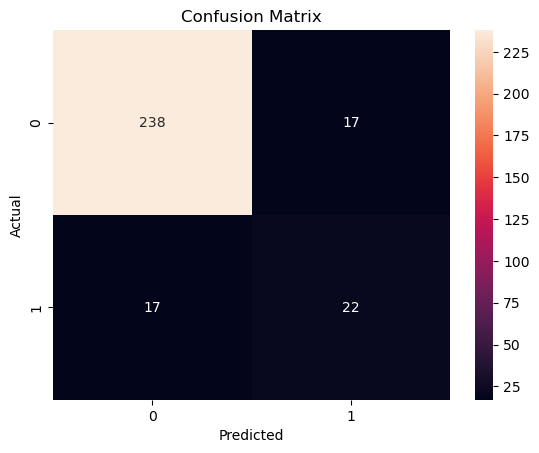

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Comparing co-efficients

In [20]:
# Get coefficients
coef_l1 = pd.Series(model_l1.coef_[0], index=X.columns)
coef_l2 = pd.Series(model_l2.coef_[0], index=X.columns)

# Sort
coef_l1 = coef_l1.sort_values()
coef_l2 = coef_l2.sort_values()

print("L1 Important Features:\n", coef_l1.tail(10))
print("\nL2 Important Features:\n", coef_l2.tail(10))

L1 Important Features:
 HourlyRate                          0.036056
Gender_Male                         0.046572
MonthlyRate                         0.059041
BusinessTravel_Travel_Frequently    0.152673
DistanceFromHome                    0.244993
YearsSinceLastPromotion             0.378513
NumCompaniesWorked                  0.400775
YearsAtCompany                      0.665715
MonthlyIncome                       0.758169
OverTime_Yes                        0.820351
dtype: float64

L2 Important Features:
 HourlyRate                          0.044761
Gender_Male                         0.056275
MonthlyRate                         0.067099
BusinessTravel_Travel_Frequently    0.159537
DistanceFromHome                    0.251863
YearsSinceLastPromotion             0.384978
NumCompaniesWorked                  0.414495
YearsAtCompany                      0.696288
MonthlyIncome                       0.800357
OverTime_Yes                        0.828185
dtype: float64


### ROC - AUC score comparison

In [21]:
from sklearn.metrics import roc_auc_score

print("L1 ROC-AUC:", roc_auc_score(y_test, y_pred_prob_l1))
print("L2 ROC-AUC:", roc_auc_score(y_test, y_pred_l2_prob))

L1 ROC-AUC: 0.7897435897435897
L2 ROC-AUC: 0.7487179487179487
